# Online Retail II — Customer Segmentation

This notebook applies Recency, Frequency, and Monetary (RFM) analysis to identified customers. Customer segments are created to support retention, reactivation, and high-value customer strategies.

Only eligible merchandise transactions with valid customer IDs are used. Anonymous transactions remain part of company-level revenue reporting but cannot be assigned to customer segments.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "retail_transactions_clean.csv.gz"
)

print("Project root:", project_root)
print("Dataset path:", data_path)
print("Dataset exists:", data_path.exists())

Project root: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics
Dataset path: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\processed\retail_transactions_clean.csv.gz
Dataset exists: True


In [3]:
column_types = {
    "invoice_no": "string",
    "stock_code": "string",
    "description": "string",
    "quantity": "int64",
    "unit_price": "float64",
    "customer_id": "Int64",
    "country": "string",
    "source_year": "string",
    "transaction_type": "category",
    "line_category": "category",
    "line_value": "float64",
    "data_quality_flag": "category",
    "analysis_eligible": "boolean",
}

transactions = pd.read_csv(
    data_path,
    compression="gzip",
    dtype=column_types,
    parse_dates=["invoice_date"],
)

print("Dataset shape:", transactions.shape)
print(
    "Date range:",
    transactions["invoice_date"].min(),
    "to",
    transactions["invoice_date"].max(),
)

display(transactions.head())

Dataset shape: (1033036, 14)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_year,transaction_type,line_category,line_value,data_quality_flag,analysis_eligible
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,83.40,Standard,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,100.80,Standard,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,30.00,Standard,True


## Customer Analysis Scope

Customer-level analysis includes eligible merchandise sales and cancellations with valid customer IDs.

RFM methodology:

- Recency is based on the most recent positive merchandise purchase.
- Frequency is based on distinct positive sales invoices.
- Gross monetary value is based on positive merchandise sales.
- Cancellation value is measured separately.
- Net monetary value equals gross sales minus cancellation value.

The analysis date is set to one day after the final transaction date in the dataset.

In [4]:
identified_customer_activity = transactions.loc[
    transactions["customer_id"].notna()
    & transactions["line_category"].eq("Merchandise")
    & transactions["transaction_type"].isin(
        ["Sale", "Cancellation"]
    )
    & transactions["analysis_eligible"].eq(True)
].copy()

identified_customer_activity["gross_sales_value"] = np.where(
    identified_customer_activity[
        "transaction_type"
    ].eq("Sale"),
    identified_customer_activity["line_value"],
    0.0,
)

identified_customer_activity["cancellation_value"] = np.where(
    identified_customer_activity[
        "transaction_type"
    ].eq("Cancellation"),
    identified_customer_activity["line_value"].abs(),
    0.0,
)

identified_customer_activity["net_value"] = (
    identified_customer_activity["gross_sales_value"]
    - identified_customer_activity["cancellation_value"]
)

identified_customer_sales = (
    identified_customer_activity.loc[
        identified_customer_activity[
            "transaction_type"
        ].eq("Sale")
    ]
    .copy()
)

identified_customer_cancellations = (
    identified_customer_activity.loc[
        identified_customer_activity[
            "transaction_type"
        ].eq("Cancellation")
    ]
    .copy()
)

analysis_date = (
    transactions["invoice_date"]
    .max()
    .normalize()
    + pd.Timedelta(days=1)
)

print(
    "Identified merchandise sales rows:",
    f"{len(identified_customer_sales):,}",
)

print(
    "Identified merchandise cancellation rows:",
    f"{len(identified_customer_cancellations):,}",
)

print(
    "Customers with positive sales:",
    f"{identified_customer_sales['customer_id'].nunique():,}",
)

print("Analysis date:", analysis_date.date())

Identified merchandise sales rows: 776,595
Identified merchandise cancellation rows: 17,587
Customers with positive sales: 5,852
Analysis date: 2011-12-10


## Customer Metric Construction

Customer purchase and cancellation activity is aggregated to create:

- First and most recent purchase dates
- Recency and customer tenure
- Distinct purchase frequency
- Gross and net monetary value
- Units and distinct products purchased
- Cancellation behavior
- Primary purchasing country

In [5]:
customer_sales_metrics = (
    identified_customer_sales
    .groupby("customer_id", observed=True)
    .agg(
        first_purchase_date=("invoice_date", "min"),
        last_purchase_date=("invoice_date", "max"),
        frequency=("invoice_no", "nunique"),
        purchase_rows=("invoice_no", "size"),
        gross_monetary_value=(
            "gross_sales_value",
            "sum",
        ),
        units_purchased=("quantity", "sum"),
        distinct_products=("stock_code", "nunique"),
    )
    .reset_index()
)

customer_cancellation_metrics = (
    identified_customer_cancellations
    .groupby("customer_id", observed=True)
    .agg(
        cancellation_invoices=("invoice_no", "nunique"),
        cancellation_value=("cancellation_value", "sum"),
        cancelled_units=(
            "quantity",
            lambda values: values.abs().sum(),
        ),
    )
    .reset_index()
)

customer_country_summary = (
    identified_customer_sales
    .groupby(
        ["customer_id", "country"],
        observed=True,
    )
    .agg(
        country_invoices=("invoice_no", "nunique"),
        country_sales=("gross_sales_value", "sum"),
    )
    .reset_index()
    .sort_values(
        [
            "customer_id",
            "country_invoices",
            "country_sales",
            "country",
        ],
        ascending=[True, False, False, True],
    )
)

primary_customer_country = (
    customer_country_summary
    .drop_duplicates(subset=["customer_id"])
    [["customer_id", "country"]]
    .rename(columns={"country": "primary_country"})
)

customer_metrics = (
    customer_sales_metrics
    .merge(
        customer_cancellation_metrics,
        on="customer_id",
        how="left",
    )
    .merge(
        primary_customer_country,
        on="customer_id",
        how="left",
    )
)

cancellation_columns = [
    "cancellation_invoices",
    "cancellation_value",
    "cancelled_units",
]

customer_metrics[cancellation_columns] = (
    customer_metrics[cancellation_columns].fillna(0)
)

customer_metrics[
    ["cancellation_invoices", "cancelled_units"]
] = customer_metrics[
    ["cancellation_invoices", "cancelled_units"]
].astype("int64")

customer_metrics["recency_days"] = (
    analysis_date
    - customer_metrics["last_purchase_date"]
).dt.days

customer_metrics["tenure_days"] = (
    analysis_date
    - customer_metrics["first_purchase_date"]
).dt.days

customer_metrics["net_monetary_value"] = (
    customer_metrics["gross_monetary_value"]
    - customer_metrics["cancellation_value"]
)

customer_metrics["average_order_value"] = (
    customer_metrics["gross_monetary_value"]
    / customer_metrics["frequency"]
)

customer_metrics["cancellation_rate_pct"] = (
    customer_metrics["cancellation_value"]
    / customer_metrics["gross_monetary_value"]
    * 100
)

print("Customer records:", f"{len(customer_metrics):,}")

print(
    "One-time customers:",
    f"{customer_metrics['frequency'].eq(1).sum():,}",
)

print(
    "Customers with cancellations:",
    f"{customer_metrics['cancellation_invoices'].gt(0).sum():,}",
)

print(
    "Customers with non-positive net value:",
    f"{customer_metrics['net_monetary_value'].le(0).sum():,}",
)

display(
    customer_metrics[
        [
            "recency_days",
            "frequency",
            "gross_monetary_value",
            "cancellation_value",
            "net_monetary_value",
            "average_order_value",
            "units_purchased",
            "distinct_products",
        ]
    ]
    .describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    )
    .T
)

Customer records: 5,852
One-time customers: 1,618
Customers with cancellations: 2,422
Customers with non-positive net value: 20


,count,mean,std,min,1%,25%,50%,75%,99%,max
recency_days,"5,852.00",199.73,208.52,0.00,1.00,25.00,95.00,379.00,726.00,738.00
frequency,"5,852.00",6.25,12.75,1.00,1.00,1.00,3.00,7.00,46.00,373.00
gross_monetary_value,"5,852.00","2,910.05","14,298.71",2.95,45.32,339.58,856.02,"2,238.58","27,778.36","580,987.04"
cancellation_value,"5,852.00",121.08,"2,502.98",0.00,0.00,0.00,0.00,27.41,"1,109.68","168,469.60"
net_monetary_value,"5,852.00","2,788.97","13,816.91","-1,343.24",35.55,330.94,840.16,"2,167.95","26,318.22","578,408.64"
average_order_value,"5,852.00",382.21,"1,243.31",2.95,37.45,176.15,277.87,410.56,"1,875.04","84,236.25"
units_purchased,"5,852.00","1,794.04","8,890.85",1.00,12.00,189.00,484.50,"1,352.50","16,727.64","367,072.00"
distinct_products,"5,852.00",82.19,116.50,1.00,1.00,19.00,45.00,103.00,502.98,"2,546.00"


## RFM Scoring Methodology

Customer scores range from 1 to 5, where 5 represents the strongest behavior.

### Recency score

- 5: purchased within 30 days
- 4: purchased within 31–90 days
- 3: purchased within 91–180 days
- 2: purchased within 181–365 days
- 1: last purchase was more than 365 days ago

### Frequency score

- 1: one purchase invoice
- 2: two purchase invoices
- 3: three or four purchase invoices
- 4: five to ten purchase invoices
- 5: eleven or more purchase invoices

### Monetary score

Net monetary value is divided into five customer-value quintiles. Customers with the highest net monetary values receive a score of 5.

In [6]:
customer_metrics["r_score"] = pd.cut(
    customer_metrics["recency_days"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=[5, 4, 3, 2, 1],
).astype("int64")

customer_metrics["f_score"] = pd.cut(
    customer_metrics["frequency"],
    bins=[0, 1, 2, 4, 10, np.inf],
    labels=[1, 2, 3, 4, 5],
).astype("int64")

customer_metrics["m_score"] = pd.qcut(
    customer_metrics["net_monetary_value"],
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype("int64")

customer_metrics["rfm_total_score"] = (
    customer_metrics["r_score"]
    + customer_metrics["f_score"]
    + customer_metrics["m_score"]
)

customer_metrics["rfm_code"] = (
    customer_metrics["r_score"].astype("string")
    + customer_metrics["f_score"].astype("string")
    + customer_metrics["m_score"].astype("string")
)

score_distribution = pd.DataFrame(
    {
        "Score": [1, 2, 3, 4, 5],
        "Recency Customers": [
            customer_metrics["r_score"].eq(score).sum()
            for score in range(1, 6)
        ],
        "Frequency Customers": [
            customer_metrics["f_score"].eq(score).sum()
            for score in range(1, 6)
        ],
        "Monetary Customers": [
            customer_metrics["m_score"].eq(score).sum()
            for score in range(1, 6)
        ],
    }
)

print("Monetary-value quintile boundaries:")

display(
    customer_metrics["net_monetary_value"].quantile(
        [0, 0.20, 0.40, 0.60, 0.80, 1.00]
    ).to_frame(name="Net Monetary Value")
)

display(score_distribution)

display(
    customer_metrics[
        [
            "customer_id",
            "recency_days",
            "frequency",
            "net_monetary_value",
            "r_score",
            "f_score",
            "m_score",
            "rfm_total_score",
            "rfm_code",
        ]
    ].head(10)
)

Monetary-value quintile boundaries:


,Net Monetary Value
0.00,"-1,343.24"
0.20,271.77
0.40,590.69
0.60,"1,177.25"
0.80,"2,819.36"
1.00,"578,408.64"


,Score,Recency Customers,Frequency Customers,Monetary Customers
0,1,1581,1618,1171
1,2,797,946,1170
2,3,589,1147,1170
3,4,1219,1277,1170
4,5,1666,864,1171


,customer_id,recency_days,frequency,net_monetary_value,r_score,f_score,m_score,rfm_total_score,rfm_code
0,12346,325,3,169.36,2,3,1,6,231
1,12347,2,8,"4,921.53",5,4,5,14,545
2,12348,75,5,"1,658.40",4,4,4,12,444
3,12349,18,3,"3,654.54",5,3,5,13,535
4,12350,310,1,294.40,2,1,2,5,212
5,12351,375,1,300.93,1,1,2,4,112
6,12352,36,9,"1,609.21",4,4,4,12,444
7,12353,204,2,406.76,2,2,2,6,222
8,12354,232,1,"1,079.40",2,1,3,6,213
9,12355,214,2,947.61,2,2,3,7,223


## Customer Segment Assignment

Customers are assigned to actionable segments using their RFM scores:

- Champions: recent, frequent, and high-value customers
- Loyal Customers: active customers with high purchase frequency
- New Customers: first-time customers acquired recently
- Potential Loyalists: recent customers with developing purchase frequency
- Promising Customers: recent one-time customers
- High-Value Active: active high-spending customers not captured above
- Need Attention: moderately recent customers showing declining engagement
- At Risk: previously valuable or frequent customers who have become inactive
- Hibernating: inactive customers with low purchase frequency
- Regular Customers: customers not captured by the specialized segments

In [7]:
segment_conditions = [
    (
        customer_metrics["r_score"].ge(4)
        & customer_metrics["f_score"].ge(4)
        & customer_metrics["m_score"].ge(4)
    ),
    (
        customer_metrics["r_score"].ge(3)
        & customer_metrics["f_score"].ge(4)
    ),
    (
        customer_metrics["r_score"].eq(5)
        & customer_metrics["f_score"].eq(1)
    ),
    (
        customer_metrics["r_score"].ge(4)
        & customer_metrics["f_score"].between(2, 3)
    ),
    (
        customer_metrics["r_score"].eq(4)
        & customer_metrics["f_score"].eq(1)
    ),
    (
        customer_metrics["m_score"].eq(5)
        & customer_metrics["r_score"].ge(3)
    ),
    (
        customer_metrics["r_score"].eq(3)
        & (
            customer_metrics["f_score"].ge(2)
            | customer_metrics["m_score"].ge(3)
        )
    ),
    (
        customer_metrics["r_score"].le(2)
        & (
            customer_metrics["f_score"].ge(3)
            | customer_metrics["m_score"].ge(4)
        )
    ),
    (
        customer_metrics["r_score"].le(2)
        & customer_metrics["f_score"].le(2)
    ),
]

segment_names = [
    "Champions",
    "Loyal Customers",
    "New Customers",
    "Potential Loyalists",
    "Promising Customers",
    "High-Value Active",
    "Need Attention",
    "At Risk",
    "Hibernating",
]

customer_metrics["customer_segment"] = np.select(
    segment_conditions,
    segment_names,
    default="Regular Customers",
)

segment_summary = (
    customer_metrics
    .groupby("customer_segment", observed=True)
    .agg(
        customer_count=("customer_id", "nunique"),
        average_recency_days=("recency_days", "mean"),
        average_frequency=("frequency", "mean"),
        gross_monetary_value=(
            "gross_monetary_value",
            "sum",
        ),
        cancellation_value=("cancellation_value", "sum"),
        net_monetary_value=("net_monetary_value", "sum"),
        average_customer_value=(
            "net_monetary_value",
            "mean",
        ),
    )
    .reset_index()
)

segment_summary["customer_share_pct"] = (
    segment_summary["customer_count"]
    / segment_summary["customer_count"].sum()
    * 100
)

segment_summary["net_revenue_share_pct"] = (
    segment_summary["net_monetary_value"]
    / segment_summary["net_monetary_value"].sum()
    * 100
)

segment_summary["cancellation_rate_pct"] = (
    segment_summary["cancellation_value"]
    / segment_summary["gross_monetary_value"]
    * 100
)

segment_summary = segment_summary.sort_values(
    "net_monetary_value",
    ascending=False,
).reset_index(drop=True)

print(
    "Customers assigned to segments:",
    f"{segment_summary['customer_count'].sum():,}",
)

display(segment_summary)

Customers assigned to segments: 5,852


,customer_segment,customer_count,average_recency_days,average_frequency,gross_monetary_value,cancellation_value,net_monetary_value,average_customer_value,customer_share_pct,net_revenue_share_pct,cancellation_rate_pct
0,Champions,1448,26.05,16.29,"12,393,877.08","309,012.38","12,084,864.70","8,345.90",24.74,74.04,2.49
1,At Risk,803,359.14,5.17,"1,727,998.17","161,173.33","1,566,824.84","1,951.21",13.72,9.60,9.33
2,Potential Loyalists,907,35.04,2.89,"1,081,827.63","195,788.83","886,038.80",976.89,15.50,5.43,18.10
3,Loyal Customers,391,86.48,7.68,"873,584.75","18,308.71","855,276.04","2,187.41",6.68,5.24,2.10
4,Hibernating,1575,452.10,1.29,"527,079.76","15,233.65","511,846.11",324.98,26.91,3.14,2.89
5,Need Attention,253,136.13,2.78,"216,354.05","4,736.20","211,617.85",836.43,4.32,1.30,2.19
6,Promising Customers,235,59.52,1.00,"97,890.90","3,364.99","94,525.91",402.24,4.02,0.58,3.44
7,High-Value Active,12,133.75,3.17,"47,009.73",185.20,"46,824.53","3,902.04",0.21,0.29,0.39
8,New Customers,132,17.04,1.00,"41,423.15",583.81,"40,839.34",309.39,2.26,0.25,1.41
9,Regular Customers,96,133.27,1.00,"22,567.51",196.80,"22,370.71",233.03,1.64,0.14,0.87


### Customer Segment Findings

- Champions represent 24.74% of customers but generate 74.04% of identified-customer net revenue.
- Champions purchase frequently, have an average recency of 26 days, and generate an average net value of £8,345.90 per customer.
- At Risk customers contribute 9.60% of net revenue and have an average recency of 359 days, making them the highest-priority reactivation group.
- Potential Loyalists represent 15.50% of customers and purchased recently, providing a strong opportunity for repeat-purchase campaigns.
- Hibernating customers represent 26.91% of customers but contribute only 3.14% of net revenue.
- Cancellation behavior should be monitored carefully for At Risk and Potential Loyalist customers.

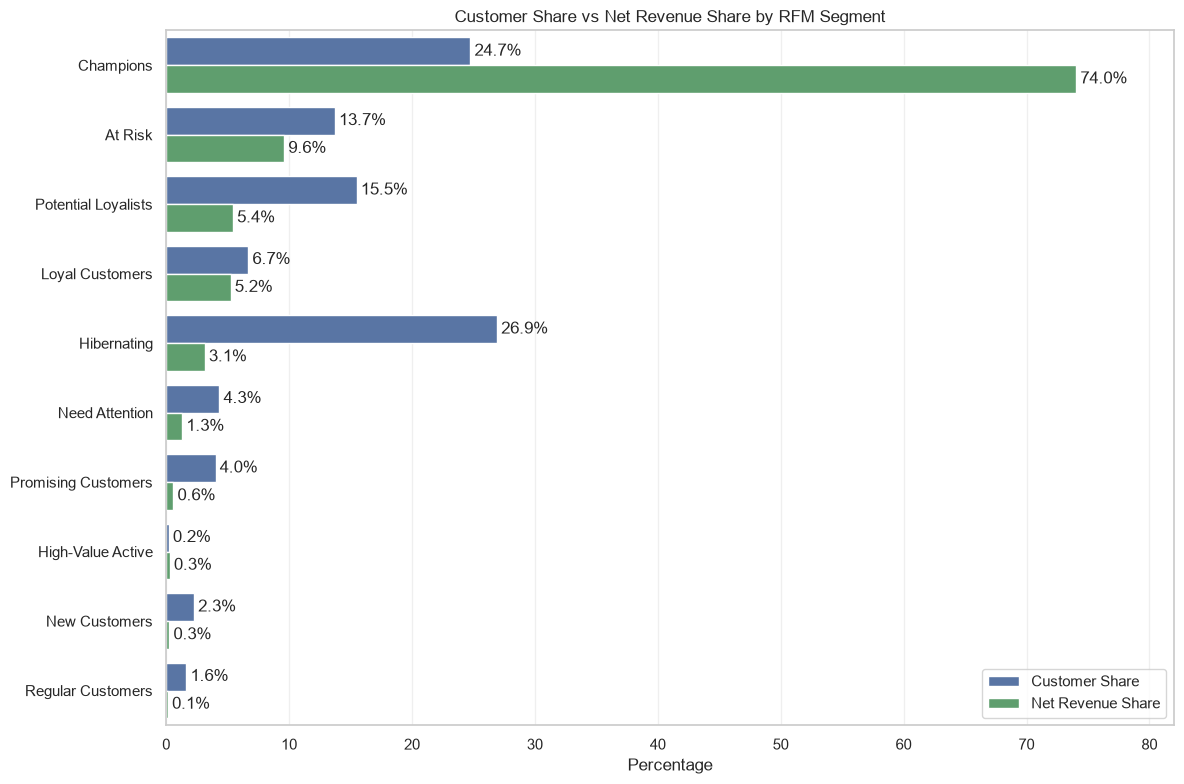

In [8]:
segment_chart_data = segment_summary.melt(
    id_vars="customer_segment",
    value_vars=[
        "customer_share_pct",
        "net_revenue_share_pct",
    ],
    var_name="metric",
    value_name="percentage",
)

segment_chart_data["metric"] = (
    segment_chart_data["metric"].map(
        {
            "customer_share_pct": "Customer Share",
            "net_revenue_share_pct": "Net Revenue Share",
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=segment_chart_data,
    y="customer_segment",
    x="percentage",
    hue="metric",
    palette=["#4C72B0", "#55A868"],
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

ax.set_title(
    "Customer Share vs Net Revenue Share by RFM Segment"
)
ax.set_xlabel("Percentage")
ax.set_ylabel("")
ax.set_xlim(0, 82)
ax.legend(title="")
ax.grid(axis="x", alpha=0.30)

plt.tight_layout()
plt.show()

## At-Risk Customer Reactivation

At Risk customers previously purchased frequently or generated high value but have not purchased recently. They are ranked by historical net monetary value to identify the highest-priority reactivation opportunities.

In [9]:
at_risk_customers = (
    customer_metrics.loc[
        customer_metrics["customer_segment"].eq("At Risk")
        & customer_metrics["net_monetary_value"].gt(0)
    ]
    .sort_values(
        "net_monetary_value",
        ascending=False,
    )
    .copy()
)

at_risk_customers["reactivation_priority_rank"] = (
    at_risk_customers["net_monetary_value"]
    .rank(
        method="first",
        ascending=False,
    )
    .astype("int64")
)

top_at_risk_customers = (
    at_risk_customers.head(20).copy()
)

top_20_at_risk_revenue_share = (
    top_at_risk_customers["net_monetary_value"].sum()
    / at_risk_customers["net_monetary_value"].sum()
    * 100
)

print(
    "Positive-value At Risk customers:",
    f"{len(at_risk_customers):,}",
)

print(
    "Total At Risk net value:",
    f"£{at_risk_customers['net_monetary_value'].sum():,.2f}",
)

print(
    "Top 20 share of At Risk net value:",
    f"{top_20_at_risk_revenue_share:.2f}%",
)

at_risk_columns = [
    "reactivation_priority_rank",
    "customer_id",
    "primary_country",
    "recency_days",
    "frequency",
    "gross_monetary_value",
    "cancellation_value",
    "net_monetary_value",
    "average_order_value",
    "r_score",
    "f_score",
    "m_score",
]

display(
    top_at_risk_customers[at_risk_columns]
)

Positive-value At Risk customers: 803
Total At Risk net value: £1,566,824.84
Top 20 share of At Risk net value: 25.38%


,reactivation_priority_rank,customer_id,primary_country,recency_days,frequency,gross_monetary_value,cancellation_value,net_monetary_value,average_order_value,r_score,f_score,m_score
4340,1,16754,United Kingdom,372,29,"65,500.07","10,807.25","54,692.82","2,258.62",1,5,5
734,2,13093,United Kingdom,275,55,"54,144.25",860.95,"53,283.30",984.44,2,5,5
5416,3,17850,United Kingdom,372,155,"51,208.87",801.10,"50,407.77",330.38,1,5,5
1527,4,13902,Denmark,632,5,"34,023.26","3,648.00","30,375.26","6,804.65",1,4,5
133,5,12482,Sweden,576,27,"21,941.72",0.00,"21,941.72",812.66,1,5,5
3351,6,15749,United Kingdom,235,3,"44,534.30","22,998.40","21,535.90","14,844.77",2,3,5
3407,7,15808,United Kingdom,306,21,"17,180.25",141.30,"17,038.95",818.11,2,5,5
1193,8,13564,United Kingdom,354,36,"15,880.22",267.12,"15,613.10",441.12,2,5,5
5024,9,17448,United Kingdom,529,41,"14,448.67",73.66,"14,375.01",352.41,1,5,5
5651,10,18087,United Kingdom,290,16,"13,908.72",345.10,"13,563.62",869.30,2,5,5


### At-Risk Reactivation Findings

- All 803 At Risk customers retain positive historical net value.
- The segment represents £1,566,824.84 in historical net revenue.
- The 20 highest-value At Risk customers account for 25.38% of the segment's net value.
- The highest-priority customers combine substantial historical value with long periods of inactivity.
- Customer 17850 placed 155 historical sales invoices but has been inactive for 372 days.
- Customer 15749 has a high cancellation value, indicating that service recovery should occur before promotional reactivation.
- Reactivation campaigns should prioritize the highest-value customers rather than applying broad discounts to the entire segment.

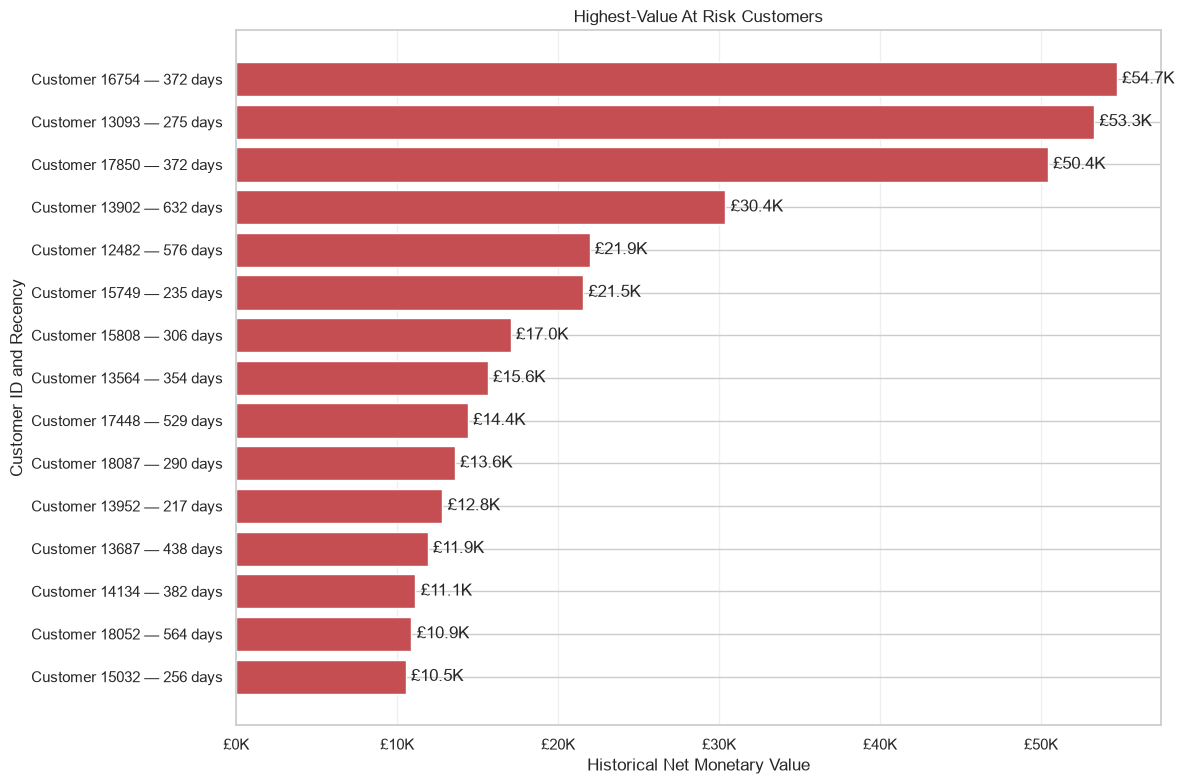

In [10]:
top_at_risk_chart = (
    top_at_risk_customers
    .head(15)
    .sort_values("net_monetary_value")
    .copy()
)

top_at_risk_chart["customer_label"] = (
    "Customer "
    + top_at_risk_chart["customer_id"].astype("string")
    + " — "
    + top_at_risk_chart["recency_days"].astype("string")
    + " days"
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_at_risk_chart["customer_label"],
    top_at_risk_chart["net_monetary_value"],
    color="#C44E52",
)

ax.bar_label(
    bars,
    labels=[
        f"£{value / 1_000:,.1f}K"
        for value in top_at_risk_chart[
            "net_monetary_value"
        ]
    ],
    padding=4,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
        f"£{value / 1_000:,.0f}K"
    )
)

ax.set_title(
    "Highest-Value At Risk Customers"
)
ax.set_xlabel("Historical Net Monetary Value")
ax.set_ylabel("Customer ID and Recency")
ax.grid(axis="x", alpha=0.30)

plt.tight_layout()
plt.show()

## Segment Action Plan

Each customer segment is connected to a specific commercial objective, recommended action, and success metric. This converts the RFM analysis into an actionable customer-retention strategy.

In [11]:
segment_strategy = pd.DataFrame(
    [
        {
            "customer_segment": "Champions",
            "business_objective": "Retain and reward",
            "recommended_action": (
                "Provide VIP benefits, early product access, "
                "and personalized cross-sell offers"
            ),
            "primary_kpi": "Repeat purchase rate",
        },
        {
            "customer_segment": "Loyal Customers",
            "business_objective": "Increase customer value",
            "recommended_action": (
                "Use loyalty rewards, product bundles, "
                "and relevant recommendations"
            ),
            "primary_kpi": "Purchase frequency",
        },
        {
            "customer_segment": "New Customers",
            "business_objective": "Drive a second purchase",
            "recommended_action": (
                "Provide onboarding communication and "
                "a time-limited next-order incentive"
            ),
            "primary_kpi": "Second-purchase rate",
        },
        {
            "customer_segment": "Potential Loyalists",
            "business_objective": "Develop repeat behavior",
            "recommended_action": (
                "Use personalized recommendations and "
                "repeat-purchase incentives"
            ),
            "primary_kpi": "Repeat purchase rate",
        },
        {
            "customer_segment": "Promising Customers",
            "business_objective": "Build engagement",
            "recommended_action": (
                "Use product reminders, social proof, "
                "and category-based recommendations"
            ),
            "primary_kpi": "90-day repeat rate",
        },
        {
            "customer_segment": "High-Value Active",
            "business_objective": "Protect high-value relationships",
            "recommended_action": (
                "Provide priority service and personalized "
                "account-level communication"
            ),
            "primary_kpi": "Customer retention rate",
        },
        {
            "customer_segment": "Need Attention",
            "business_objective": "Prevent customer lapse",
            "recommended_action": (
                "Send targeted re-engagement offers based "
                "on previous purchasing behavior"
            ),
            "primary_kpi": "Re-engagement rate",
        },
        {
            "customer_segment": "At Risk",
            "business_objective": "Reactivate valuable customers",
            "recommended_action": (
                "Prioritize high-value customers for "
                "personalized win-back and service recovery"
            ),
            "primary_kpi": "Reactivation rate",
        },
        {
            "customer_segment": "Hibernating",
            "business_objective": "Test low-cost reactivation",
            "recommended_action": (
                "Use automated reactivation campaigns "
                "with controlled promotional costs"
            ),
            "primary_kpi": "Cost per reactivated customer",
        },
        {
            "customer_segment": "Regular Customers",
            "business_objective": "Increase engagement",
            "recommended_action": (
                "Use relevant product recommendations "
                "and purchase-frequency incentives"
            ),
            "primary_kpi": "Purchase frequency",
        },
    ]
)

segment_action_plan = (
    segment_summary[
        [
            "customer_segment",
            "customer_count",
            "average_recency_days",
            "average_frequency",
            "net_monetary_value",
            "customer_share_pct",
            "net_revenue_share_pct",
        ]
    ]
    .merge(
        segment_strategy,
        on="customer_segment",
        how="left",
    )
    .sort_values(
        "net_monetary_value",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(segment_action_plan)

,customer_segment,customer_count,average_recency_days,average_frequency,net_monetary_value,customer_share_pct,net_revenue_share_pct,business_objective,recommended_action,primary_kpi
0,Champions,1448,26.05,16.29,"12,084,864.70",24.74,74.04,Retain and reward,"Provide VIP benefits, early product access, an...",Repeat purchase rate
1,At Risk,803,359.14,5.17,"1,566,824.84",13.72,9.60,Reactivate valuable customers,Prioritize high-value customers for personaliz...,Reactivation rate
2,Potential Loyalists,907,35.04,2.89,"886,038.80",15.50,5.43,Develop repeat behavior,Use personalized recommendations and repeat-pu...,Repeat purchase rate
3,Loyal Customers,391,86.48,7.68,"855,276.04",6.68,5.24,Increase customer value,"Use loyalty rewards, product bundles, and rele...",Purchase frequency
4,Hibernating,1575,452.10,1.29,"511,846.11",26.91,3.14,Test low-cost reactivation,Use automated reactivation campaigns with cont...,Cost per reactivated customer
5,Need Attention,253,136.13,2.78,"211,617.85",4.32,1.30,Prevent customer lapse,Send targeted re-engagement offers based on pr...,Re-engagement rate
6,Promising Customers,235,59.52,1.00,"94,525.91",4.02,0.58,Build engagement,"Use product reminders, social proof, and categ...",90-day repeat rate
7,High-Value Active,12,133.75,3.17,"46,824.53",0.21,0.29,Protect high-value relationships,Provide priority service and personalized acco...,Customer retention rate
8,New Customers,132,17.04,1.00,"40,839.34",2.26,0.25,Drive a second purchase,Provide onboarding communication and a time-li...,Second-purchase rate
9,Regular Customers,96,133.27,1.00,"22,370.71",1.64,0.14,Increase engagement,Use relevant product recommendations and purch...,Purchase frequency


## Export Customer Segmentation Tables

Customer-level RFM results, segment summaries, reactivation priorities, and segment strategies are exported for Snowflake, SQL, and Tableau analysis.

In [12]:
analytics_path = (
    project_root
    / "data"
    / "processed"
    / "analytics"
)

analytics_path.mkdir(
    parents=True,
    exist_ok=True,
)

customer_export_columns = [
    "customer_id",
    "primary_country",
    "first_purchase_date",
    "last_purchase_date",
    "recency_days",
    "tenure_days",
    "frequency",
    "purchase_rows",
    "units_purchased",
    "distinct_products",
    "gross_monetary_value",
    "cancellation_invoices",
    "cancellation_value",
    "cancelled_units",
    "net_monetary_value",
    "average_order_value",
    "cancellation_rate_pct",
    "r_score",
    "f_score",
    "m_score",
    "rfm_total_score",
    "rfm_code",
    "customer_segment",
]

customer_rfm_export = customer_metrics[
    customer_export_columns
].copy()

customer_exports = {
    "customer_rfm_segments.csv": customer_rfm_export,
    "customer_segment_summary.csv": segment_summary,
    "segment_action_plan.csv": segment_action_plan,
    "top_at_risk_customers.csv": top_at_risk_customers[
        at_risk_columns
    ],
    "rfm_score_distribution.csv": score_distribution,
}

customer_export_records = []

for file_name, dataframe in customer_exports.items():
    export_path = analytics_path / file_name

    dataframe.to_csv(
        export_path,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    customer_export_records.append(
        {
            "file": str(
                export_path.relative_to(project_root)
            ),
            "rows": len(dataframe),
            "size_kb": (
                export_path.stat().st_size / 1024
            ),
        }
    )

customer_export_manifest = pd.DataFrame(
    customer_export_records
)

display(customer_export_manifest)

print(
    "Customer segmentation exports completed successfully."
)

,file,rows,size_kb
0,data\processed\analytics\customer_rfm_segments...,5852,893.16
1,data\processed\analytics\customer_segment_summ...,10,1.78
2,data\processed\analytics\segment_action_plan.csv,10,2.31
3,data\processed\analytics\top_at_risk_customers...,20,1.73
4,data\processed\analytics\rfm_score_distributio...,5,0.15


Customer segmentation exports completed successfully.


## Customer Segmentation Summary

### Analytical scope

- Identified customers analyzed: 5,852
- Analysis date: 10 December 2011
- One-time customers: 1,618
- Customers with cancellation activity: 2,422
- Customers with non-positive net value: 20
- Median customer recency: 95 days
- Median purchase frequency: 3 invoices
- Median net monetary value: £840.16

### RFM segmentation

- Champions: 1,448 customers, representing 24.74% of customers and 74.04% of identified-customer net revenue
- At Risk: 803 customers, representing 13.72% of customers and 9.60% of net revenue
- Potential Loyalists: 907 customers, representing 15.50% of customers and 5.43% of net revenue
- Loyal Customers: 391 customers, representing 6.68% of customers and 5.24% of net revenue
- Hibernating: 1,575 customers, representing 26.91% of customers but only 3.14% of net revenue

### Reactivation opportunity

- At Risk customers retain £1,566,824.84 in historical net value.
- The 20 highest-value At Risk customers account for 25.38% of the segment's historical net value.
- Customer 17850 placed 155 sales invoices but has been inactive for 372 days.
- Customer 15749 requires service recovery consideration because of substantial cancellation activity.
- High-value At Risk customers should receive personalized outreach before broad discount campaigns are considered.

### Recommended strategy

- Retain Champions using VIP treatment, early access, and personalized cross-selling.
- Convert Potential Loyalists through relevant recommendations and repeat-purchase incentives.
- Encourage New and Promising Customers to make a second purchase.
- Prioritize high-value At Risk customers for personalized reactivation.
- Use low-cost automated campaigns for Hibernating customers.
- Monitor reactivation, repeat-purchase, purchase-frequency, and customer-retention KPIs by segment.

### Analytical limitations

- RFM segmentation describes historical customer behavior and does not predict future purchases.
- Anonymous transactions are excluded from customer segmentation.
- Monetary value is adjusted for customer-linked merchandise cancellations.
- Segment thresholds are business rules and should be reviewed as customer behavior changes.